<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/architectures/cnn/experiment_cnn_image_classification_binary_multiclass_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


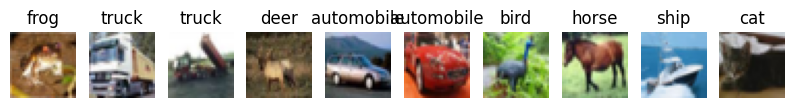

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 87ms/step - accuracy: 0.3428 - loss: 1.8097 - val_accuracy: 0.5183 - val_loss: 1.3681
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 83ms/step - accuracy: 0.5509 - loss: 1.2702 - val_accuracy: 0.5819 - val_loss: 1.1911
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 88ms/step - accuracy: 0.6142 - loss: 1.1015 - val_accuracy: 0.6045 - val_loss: 1.1306
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 86ms/step - accuracy: 0.6518 - loss: 1.0085 - val_accuracy: 0.6468 - val_loss: 1.0331
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.6808 - loss: 0.9261 - val_accuracy: 0.6582 - val_loss: 0.9902
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6627 - loss: 0.9740
Multiclass Test Accuracy: 0.66
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - accuracy: 0.5348 - loss: 0.6856 - val_accuracy: 0.6300 - val_loss: 0.6441
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/step - accuracy: 0.6579 - loss: 0.6217 - val_accuracy: 0.6855 - val_lo

In [ ]:
# IMAGE CLASSIFIER PROJECT ( BINARY & MULTICLASS )


# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical


# Load CIFAR-10 dataset (10 classes)
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# Convert labels to categorical
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Show sample images
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()


# Build CNN model for multiclass
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train model
model.fit(X_train, y_train_cat, epochs=5, batch_size=64, validation_split=0.2)


# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print(f"Multiclass Test Accuracy: {test_acc:.2f}")


# Filter CIFAR-10 for cats (label 3) and dogs (label 5)
binary_filter = (y_train.flatten() == 3) | (y_train.flatten() == 5)
X_train_bin = X_train[binary_filter]
y_train_bin = (y_train[binary_filter] == 5).astype(int)  # Dog: 1, Cat: 0

binary_filter_test = (y_test.flatten() == 3) | (y_test.flatten() == 5)
X_test_bin = X_test[binary_filter_test]
y_test_bin = (y_test[binary_filter_test] == 5).astype(int)

# Build CNN model for binary classification
binary_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

binary_model.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

# Train model
binary_model.fit(X_train_bin, y_train_bin, epochs=5, batch_size=64, validation_split=0.2)


# Evaluate binary model
binary_test_loss, binary_test_acc = binary_model.evaluate(X_test_bin, y_test_bin)
print(f"Binary Classification Accuracy (Cat vs Dog): {binary_test_acc:.2f}")
